In [1]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

import os
import sys
import git_root
sys.path.append("..")

from src.utils import *

## Dynamical Critical Exponent from Normal Mode Time Series

One method of extracting the dynamical critical exponent (DCE) from the multi-species exclusion process is to apply topological data analysis directly to the hydrodynamic normal modes since we know from our previous experimentatoin that the hydrodynamic normal mode time series if effective in splitting the process into its different regimes. The function `normal_mode_height_time_series` returns a time series of these modes in the form

$$H(t,x,m)$$

where $t$ is time, $x$ is the spatial position, and $m$ labels the hydrodynamic mode. For a fixed mode $m$, each time slice gives a spatial height profile

$$h_m(t,x)$$

However at a certain time $t$ this is just a one dimensional data point with no topological features so we construct a topological observable from the shape of this profile. At each time $t$, the spatial profile is converted into a point cloud by taking local patches of length $w$. Each patch becomes one point:

$$\big(h_m(t,x), h_m(t,x+1), \ldots, h_m(t,x+w-1)\big)$$

Thus, a single height profile produces a point cloud in $\mathbb{R}^w$. This point cloud represents the collection of local spatial patterns appearing in the hydrodynamic mode at that time.

The key idea is that if the hydrodynamic mode relaxes slowly, then the topology of its patch cloud should also retain memory for a long time. Therefore, we compute the autocorrelation of the topological observable,

$$C_O(\Delta t) \langle O(t)O(t+\Delta t)\rangle_t$$

and extract a relaxation time $\tau_{\mathrm{TDA}}(L)$. This relaxation time can be defined as the first time the autocorrelation drops below $1/e$, or as the integrated autocorrelation time up to the first zero crossing.

In [ ]:
L_values = np.arange(240, 600, 15)

rates_matrix = 1 - np.diag((1, 1, 1))
# rates_matrix = np.triu(np.ones((3, 3), dtype=np.float64), k=1)

mode_index = 0

n_samples = 6000
sample_every = 25

patch_divisor = 8
patch_stride = 1

N_runs = 4
tda_every = 2

taus = []

Note the following simulation may take upwards of $12 \frac 12$ hours to run on the Purdue Negishi & Bell supercomputers, below will outline how to submit the job on engines through slurm to speed up computation to at least `NUM_ENGINES` fold.

In [ ]:
checkpoint_path = f"{git_root.git_root()}/data/slurm-jobs/h0_total_persistance_slow_run_notebook.npz"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

if os.path.exists(checkpoint_path):
    data = np.load(checkpoint_path, allow_pickle=True)

    old_L_values = data["L_values"]
    taus = list(data["taus"])
    done = data["done"].astype(bool)

    print("Loaded checkpoint:", checkpoint_path)
    print(f"Completed L values: {np.sum(done)} / {len(L_values)}")

else:
    taus = [np.nan for _ in L_values]
    done = np.zeros(len(L_values), dtype=bool)

    print("Starting new checkpoint:", checkpoint_path)

In [ ]:
for L_index, L in enumerate(tqdm(L_values, smoothing=0)):
    if done[L_index]:
        continue

    tau_runs = []

    for run_id in range(N_runs):
        process = MultiSpeciesExclusionProcess(dimension=3, density=[1/3, 1/3, 1/3], rates_matrix=rates_matrix, length=int(L))

        H = process.normal_mode_height_time_series(n_samples=n_samples, sample_every=sample_every)

        patch_window = max(8, int(L) // patch_divisor)

        n_times = H.shape[0]
        tda_indices = np.arange(0, n_times, tda_every)

        h0_series = np.zeros(len(tda_indices), dtype=float)

        for j, t in enumerate(tda_indices):
            h_profile = H[t, :, mode_index]

            points = patch_point_cloud(h_profile, window=patch_window, stride=patch_stride)

            series[j] = h0_total_persistence(points) # this observable can be replaced by any TDA observable

        C = autocorrelation(series)

        times = np.arange(len(C)) * sample_every * tda_every
        tau = relaxation_time(C, times)

        tau_runs.append(tau)

    tau_mean = np.nanmean(tau_runs)

    taus[L_index] = tau_mean
    done[L_index] = True

    np.savez(checkpoint_path, L_values=L_values, taus=np.asarray(taus, dtype=float), done=done)

In [ ]:
taus = np.array(taus)
valid = np.isfinite(taus) & (taus > 0)

logL = np.log(L_values[valid])
logtau = np.log(taus[valid])

z, intercept = np.polyfit(logL, logtau, 1)
fit = intercept + z * logL

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(logL, logtau, "o", label="data")
plt.plot(logL, fit, "--", label=fr"fit $z \approx {z:.3f}$")

plt.xlabel(r"$\log L$")
plt.ylabel(r"$\log \tau$")
plt.title(fr"dynamical critical exponent from $H_0$ total persistence, mode {mode_index}")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## Using `ipyparallel` to Speed Up the TDA Computation on Purdue Negishi & Bell Clusters

The $H_0$ persistence calculation is expensive because we repeat the same full procedure for many system sizes $L$: simulate the process, compute the normal-mode height time series, build patch point clouds, compute $H_0$ persistence, compute the autocorrelation, and extract a relaxation time. 

Each value of $L$ is independent of the others, so this is an ideal place to use parallel computing. With `ipyparallel`, we start an IPython cluster with several engines where each engine is basically a separate Python worker process running on one CPU core. 

If we start $N$ engines, then up to $N$ different $L$ values can be computed at the same time instead of one after another. This does not make a single $L$-calculation faster, but it makes the full sweep over many $L$ values much faster.

In [2]:
import os
import time
import git_root
import subprocess
import ipyparallel as ipp
from collections import defaultdict

Below the code resets and starts the IPyParallel controller (the central process the notebook talks to). The controller doesn't do heavy computation itself, it talks between the notebook and the IPyParallel engines that will later run on the Slurm compute node.

First, it chooses the IPyParallel profile named `"default"`. The profile tells IPyParallel where to store and look for connection files, logs, and security information. Note the notebook, controller, and engines all need to use the same profile so they can find each other. Then it kills any old `ipcontroller` or `ipengine` processes owned by `$USER`. This is done to avoid accidentally connecting to stale controllers or old engines from a previous attempt. 

Then it starts a fresh ipcontroller with the `"default"` profile. The flag `--ip='*'` allows engines from other machines, such as Slurm compute nodes, to connect back to this controller, the flag `--log-to-file` saves controller logs, and the flag `--log-level=20` keeps logs caped at 20. Note `&` at the end starts the controller in the background, so notebook can continue running.

Finally the notebook creates an IPyParallel client with `ipp.Client(profile=profile)`. This client connects the notebook to the controller. At this point, the controller may have zero engines connected, so `rc.ids` may print an empty list. Note that is fine the controller is ready, but the Slurm engine job still needs to start. Once the Slurm job runs ipengine processes, those engines should register with this controller.


In [3]:
profile = "default"

subprocess.call("pkill -u $USER -f ipcontroller", shell=True)
subprocess.call("pkill -u $USER -f ipengine", shell=True)
time.sleep(3)

cmd = f"ipcontroller --profile={profile} --ip='*' --log-to-file --log-level=20 &"
print("Starting controller:")
print("Command:", cmd)
subprocess.call(cmd, shell=True)

time.sleep(5)

rc = ipp.Client(profile=profile)
print("Controller connected.")
print("Current engine IDs:", rc.ids)

Starting controller:
Command: ipcontroller --profile=default --ip='*' --log-to-file --log-level=20 &
Controller connected.
Current engine IDs: []


This will display the number of cores avalible on the `physics` account of the Purdue Negishi & Bell Clusters.

In [4]:
cmd_slist_cores = """slist | awk '$1 == "physics" {print $6}'"""
slist_cores_result = subprocess.run(cmd_slist_cores, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
CORES_AVALIBLE = int(slist_cores_result.stdout)

print("Cores avalible:", CORES_AVALIBLE)

Cores avalible: 0


This submits the Slurm job that will start the IPyParallel engines on the cluster. 

In [5]:
N_ENGINES = 24 # add only the 

# WALLTIME = "336:00:00" # 14 Day - Maximum Limit on Purdue Negishi & Bell Clusters
WALLTIME = "168:00:00" # 7 Days

repo = git_root.git_root()
cmd = f"sbatch --ntasks={N_ENGINES} --time={WALLTIME} {git_root.git_root()}/scripts/start_ipengines.sh"

result = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)

print("Command:", cmd)
print("STDOUT:", result.stdout)
if (result.stderr != ""):
    print("STDERR:", result.stderr)
print("Return code:", result.returncode)

Command: sbatch --ntasks=24 --time=168:00:00 /home/dupreti/TDA-Diffusion-Models/scripts/start_ipengines.sh
STDOUT: Submitted batch job 40047511

Return code: 0


This reconnects the notebook to the IPyParallel controller and then waits until the Slurm launched engines have registered with it.

In [6]:
rc = ipp.Client(profile="default") # creates client connected to IPyParallel controller with "default" profile
print("Initial IDs:", rc.ids) # which engines are already connected at that moment

rc.wait_for_engines(N_ENGINES, timeout=86400) # pause until 24 engines have connected or 24 hour timeout 

print("Final IDs:", rc.ids)
print("Number of engines:", len(rc.ids)) # must match number of engines

Initial IDs: []


  0%|          | 0/24 [00:00<?, ?engine/s]

Final IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Number of engines: 24


This prepares all of the IPyParallel engines so they can import your project code correctly.

In [7]:
dview = rc[:]
lbview = rc.load_balanced_view()

parent_dir = os.path.abspath("..")

dview["remote_parent_dir"] = parent_dir

This code pushes list of function names to parallel background processing engines (via `ipyparallel` direct view, `dview`) to ensure the remote workers have access to these notebook functions when running parallel tasks.

In [8]:
def push_functions_to_engines(*function_names):
    funcs = {}

    for name in function_names:
        if name not in globals():
            raise NameError(f"{name} is not defined in the notebook kernel.")

        funcs[name] = globals()[name]

    dview.push(funcs, block=True)

    print("Pushed functions to engines:")
    for name in function_names:
        print("  ", name)

imports libraries parallelly across all active `ipyparallel` background engines.

In [9]:
%%px

import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

if remote_parent_dir not in sys.path:
    sys.path.append(remote_parent_dir)

from src.utils import *

%px:   0%|          | 0/24 [00:00<?, ?tasks/s]

In [10]:
def split_run_ids(n_runs, n_batches):
    n_batches = min(int(n_batches), int(n_runs))

    batches = []
    for batch_index in range(n_batches):
        start = batch_index * n_runs // n_batches
        end = (batch_index + 1) * n_runs // n_batches
        batches.append(list(range(start, end)))

    return batches

In [11]:
def compute_tau_single_run(L, observable_name, process_name, run_id, **observable_kwargs):
    rates_matrix = np.array([[0.0, 1.0, 0.1], [1.0, 0.0, 0.1], [2.1, 2.1, 0.0]])  # one KPZ mode, one diffusive mode

    observable_function = globals()[observable_name]

    mode_indices = [0, 1]

    n_samples = 6000
    sample_every = 25

    patch_divisor = 8
    patch_stride = 1
    tda_every = 2

    patch_window = max(8, int(L) // patch_divisor)

    # Optional reproducible seed.
    # seed = 10_000_000 + 1000 * int(L) + int(run_id)
    # np.random.seed(seed)

    process = MultiSpeciesExclusionProcess(dimension=3, density=[1/3, 1/3, 1/3], rates_matrix=rates_matrix, length=int(L))

    H = process.normal_mode_height_time_series(n_samples=n_samples, sample_every=sample_every)

    n_times = H.shape[0]
    tda_indices = np.arange(0, n_times, tda_every)

    taus_for_modes = []

    for mode_index in mode_indices:
        series = np.zeros(len(tda_indices), dtype=float)

        for j, t in enumerate(tda_indices):
            h_profile = H[t, :, mode_index]

            points = patch_point_cloud(h_profile, window=patch_window, stride=patch_stride)

            series[j] = observable_function(points, **observable_kwargs)

        C = autocorrelation(series)
        times = np.arange(len(C)) * sample_every * tda_every

        tau = relaxation_time(C, times)

        taus_for_modes.append(tau)

    return taus_for_modes

In [12]:
def compute_tau_for_L_batch(L, observable_name, process_name="tda_observable", run_ids=None, observable_kwargs=None):
    if run_ids is None:
        run_ids = [0]

    if observable_kwargs is None:
        observable_kwargs = {}

    all_taus = []

    for run_id in run_ids:
        taus_for_modes = compute_tau_single_run(L=L, observable_name=observable_name, process_name=process_name, run_id=run_id, **observable_kwargs)

        all_taus.append(taus_for_modes)

    all_taus = np.asarray(all_taus, dtype=float)

    tau_sum = np.nansum(all_taus, axis=0)
    tau_count = np.sum(np.isfinite(all_taus), axis=0)

    return int(L), tau_sum, tau_count

In [13]:
def compute_tau_for_L(L, observable_name, process_name="tda_observable", observable_kwargs=None):
    if observable_kwargs is None:
        observable_kwargs = {}

    N_runs = 24
    run_ids = list(range(N_runs))

    L, tau_sum, tau_count = compute_tau_for_L_batch(L=L, observable_name=observable_name, process_name=process_name, run_ids=run_ids, observable_kwargs=observable_kwargs)

    with np.errstate(invalid="ignore", divide="ignore"):
        tau_means = tau_sum / tau_count

    return int(L), tau_means

In [14]:
def engine_loop(process_name, observable_name, delete_checkpoint_when_done=False, n_runs_total=24, **observable_kwargs,):
    start = 240
    end = 600
    step = 15
    
    L_values = np.arange(start, end, step)

    safe_process_name = safe_name(process_name) + "_notebook"

    output_dir = f"{git_root.git_root()}/data/slurm-jobs"

    checkpoint = LCheckpoint(process_name=safe_process_name, L_values=L_values, n_outputs=2, output_dir=output_dir)

    checkpoint.install_signal_handlers()
    checkpoint.print_status()

    remaining_L_values = checkpoint.remaining_L_values()

    if len(remaining_L_values) == 0:
        print("all L values already completed; loading taus from checkpoint")

        taus = np.array(checkpoint.get_results())

        if delete_checkpoint_when_done and checkpoint.is_complete():
            checkpoint.delete()

        return L_values, taus

    n_engines = len(rc.ids)

    if n_engines == 0:
        raise RuntimeError("No ipyparallel engines are connected.")

    n_unfinished_L = len(remaining_L_values)

    # If engines <= L values, use one batch per L.
    # If engines > L values, split each L into multiple run batches.
    if n_engines <= n_unfinished_L:
        batches_per_L = 1
    else:
        batches_per_L = math.ceil(n_engines / n_unfinished_L)

    batches_per_L = min(batches_per_L, n_runs_total)

    print(f"connected engines: {n_engines}")
    print(f"unfinished L values: {n_unfinished_L}")
    print(f"runs per L: {n_runs_total}")
    print(f"batches per L: {batches_per_L}")

    task_L_values = []
    task_observable_names = []
    task_process_names = []
    task_run_id_batches = []
    task_observable_kwargs = []

    for L in remaining_L_values:
        run_id_batches = split_run_ids(n_runs=n_runs_total, n_batches=batches_per_L)

        for run_ids in run_id_batches:
            task_L_values.append(int(L))
            task_observable_names.append(observable_name)
            task_process_names.append(safe_process_name)
            task_run_id_batches.append(run_ids)
            task_observable_kwargs.append(observable_kwargs)

    n_tasks = len(task_L_values)

    print(f"sending {n_tasks} run-batch jobs to {n_engines} engines...")

    async_result = lbview.map_async(compute_tau_for_L_batch, task_L_values, task_observable_names, task_process_names, task_run_id_batches, task_observable_kwargs)

    tau_sums_by_L = defaultdict(lambda: np.zeros(2, dtype=float))
    tau_counts_by_L = defaultdict(lambda: np.zeros(2, dtype=float))
    finished_batches_by_L = defaultdict(int)

    expected_batches_by_L = {int(L): batches_per_L for L in remaining_L_values}

    for L, tau_sum, tau_count in tqdm(async_result, total=n_tasks, desc="finished run-batch jobs"):
        L = int(L)

        tau_sum = np.asarray(tau_sum, dtype=float)
        tau_count = np.asarray(tau_count, dtype=float)

        tau_sums_by_L[L] += tau_sum
        tau_counts_by_L[L] += tau_count
        finished_batches_by_L[L] += 1

        # Only checkpoint an L once all its run batches have finished.
        if finished_batches_by_L[L] == expected_batches_by_L[L]:
            with np.errstate(invalid="ignore", divide="ignore"):
                tau_means = tau_sums_by_L[L] / tau_counts_by_L[L]

            checkpoint.record(L=L, values=tau_means, autosave=True)

    print("computation finished")

    taus = np.array(checkpoint.get_results())

    if delete_checkpoint_when_done and checkpoint.is_complete():
        checkpoint.delete()

    return L_values, taus

In [15]:
def plot(L_values, taus, process_name):
    taus = np.array(taus)

    plt.figure(figsize=(6.5, 4.5), dpi=300)

    for mode_index in [0, 1]:
        taus_mode = taus[:, mode_index]

        valid = np.isfinite(taus_mode) & (taus_mode > 0)

        logL = np.log(L_values[valid])
        logtau = np.log(taus_mode[valid])

        z, intercept = np.polyfit(logL, logtau, 1)
        fit = intercept + z * logL

        plt.plot(logL, logtau, "o", markersize=4, label=fr"mode {mode_index} data")
        plt.plot(logL, fit, "--", linewidth=1.5, label=fr"mode {mode_index} fit, $z \approx {z:.3f}$")

        print(f"mode {mode_index}: z = {z}")

    plt.xlabel(r"$\log L$", fontsize=12)
    plt.ylabel(r"$\log\tau$", fontsize=12)
    plt.title(fr"dynamical critical exponent from {process_name}", fontsize=14)

    plt.legend(fontsize=9, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [16]:
push_functions_to_engines("compute_tau_single_run", "compute_tau_for_L_batch", "compute_tau_for_L")

Pushed functions to engines:
   compute_tau_single_run
   compute_tau_for_L_batch
   compute_tau_for_L


## Strongly Coupled Topological Observables

### $H_0$ Total Persistence

We compute the total finite $H_0$ persistence of this point cloud. The $H_0$ persistence measures the connected-component structure of a point cloud as the filtration radius increases. Intuitively, it measures how separated or clustered the points are. If the patch cloud contains several well-separated groups, the $H_0$ persistence is larger. If the patch cloud is more tightly connected, the $H_0$ persistence is smaller. 


Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm-jobs/h0_total_persistence_notebook.npz
Completed L jobs: 24 / 24
h0_total_persistence_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 1.9603481899987427
mode 1: z = 1.4876102685283636


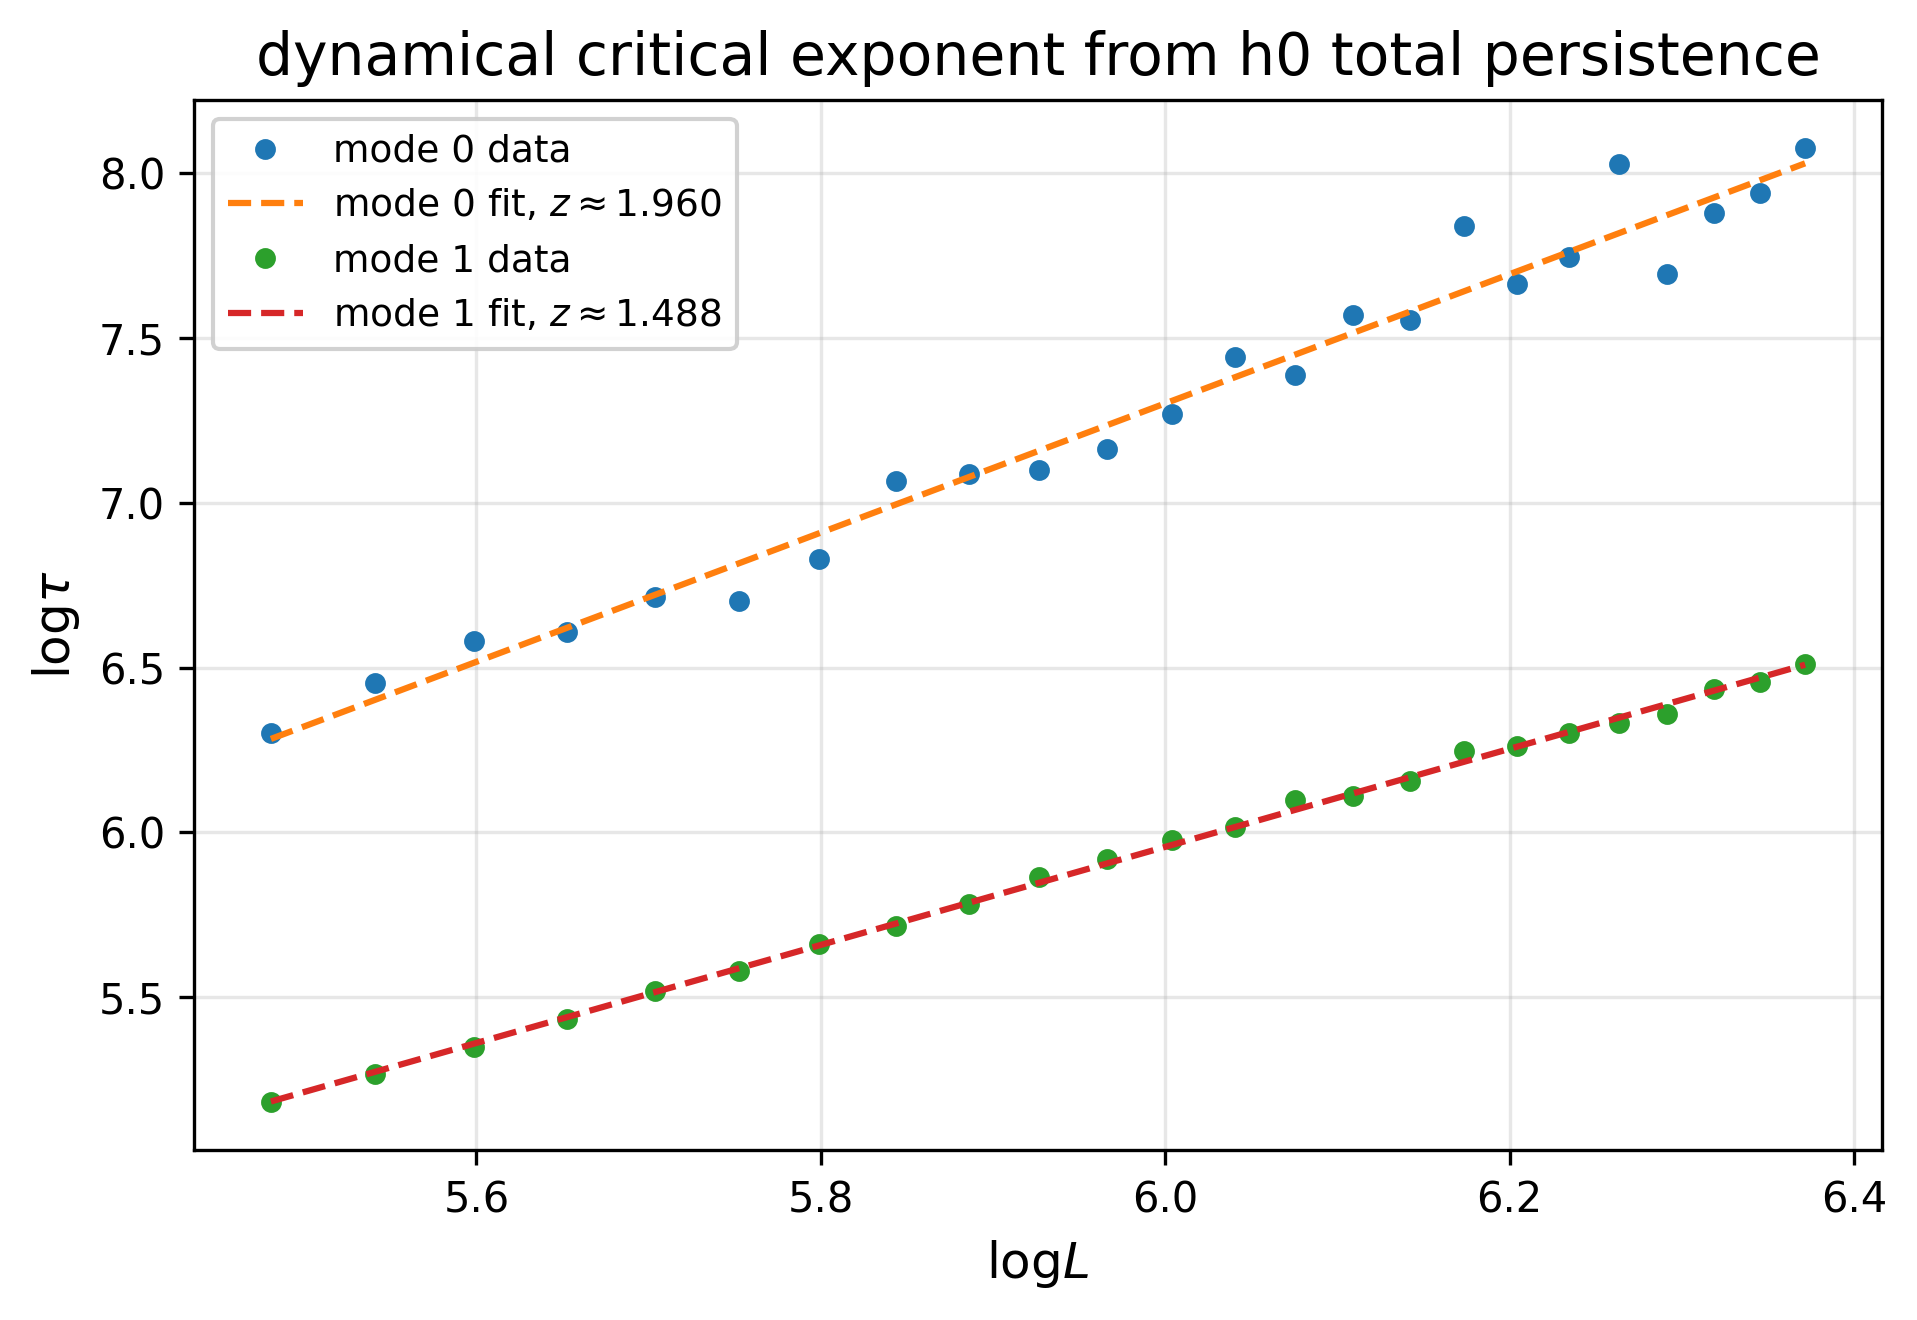

In [17]:
observable_name = "h0_total_persistence"
process_name = "h0 total persistence"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

### $H_0$ Maximum Persistence

No checkpoint found. Starting fresh:
   /home/dupreti/TDA-Diffusion-Models/data/slurm-jobs/h0_maximum_persistence_notebook.npz
h0_maximum_persistence_notebook: 0/24 L jobs complete
connected engines: 24
unfinished L values: 24
runs per L: 24
batches per L: 1
sending 24 run-batch jobs to 24 engines...


finished run-batch jobs:   4%|▍         | 1/24 [10:28<4:01:06, 628.99s/it]

completed L=240, tau=[532.01426705 179.46874693]


finished run-batch jobs:   8%|▊         | 2/24 [11:55<1:53:42, 310.10s/it]

completed L=255, tau=[638.19547794 200.57445971]


...

completed L=555, tau=[2858.77395522  621.80363429]


finished run-batch jobs:  96%|█████████▌| 23/24 [1:08:17<03:04, 184.98s/it]

completed L=570, tau=[2775.444007    660.52382188]


finished run-batch jobs: 100%|██████████| 24/24 [1:08:34<00:00, 171.43s/it]

completed L=585, tau=[2773.2353165   700.93993997]
computation finished
mode 0: z = 1.93412349139922
mode 1: z = 1.497886749274701


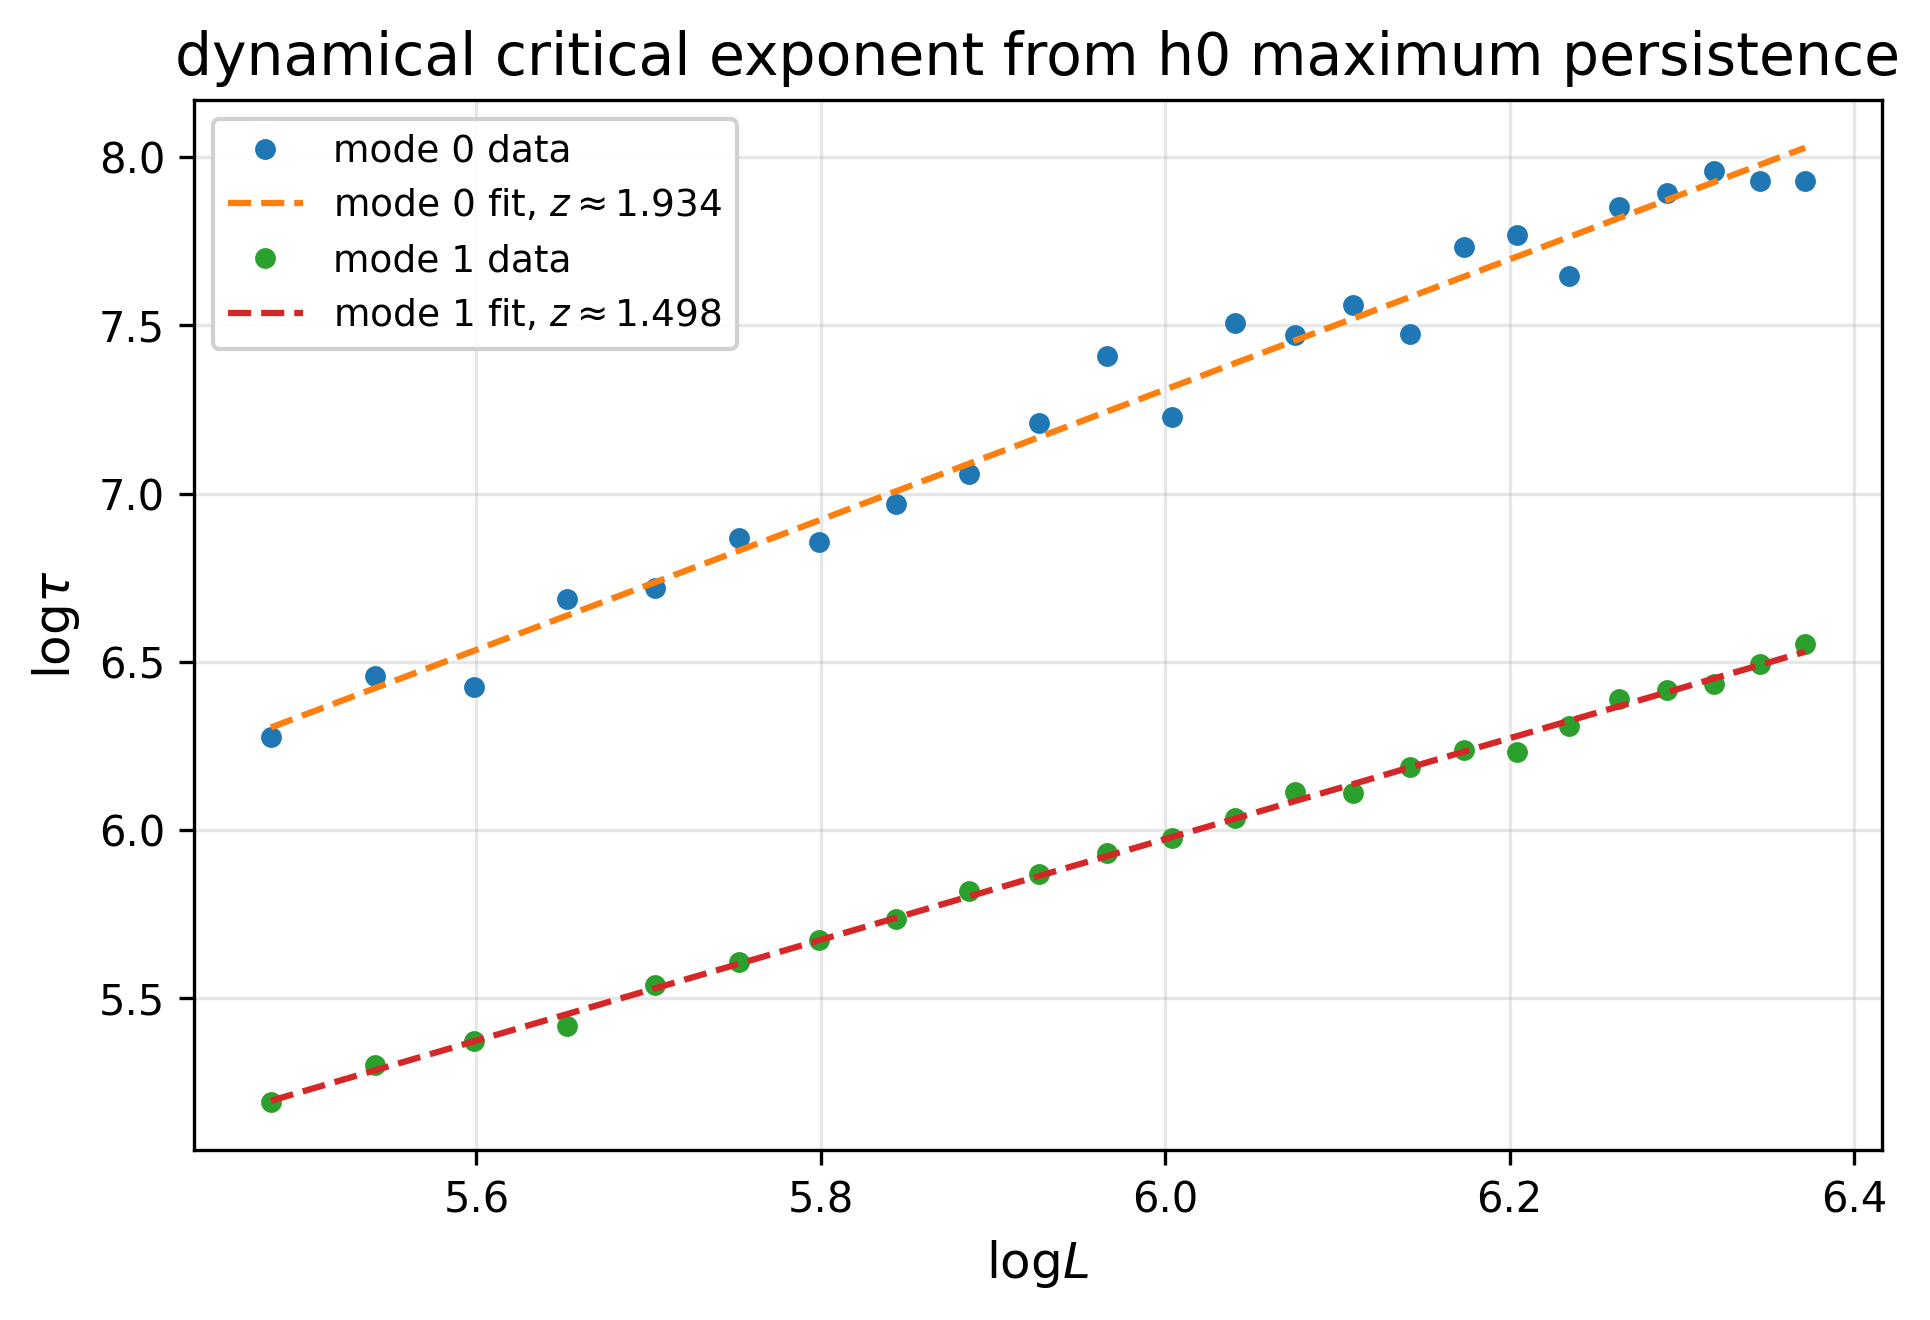

In [18]:
observable_name = "h0_max_persistence_from_points"
process_name = "h0 maximum persistence"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

### $H_1$ Total Persistence

In [ ]:
observable_name = "h1_total_persistence_from_points"
process_name = "h1 total persistence"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

No checkpoint found. Starting fresh:
   /home/dupreti/TDA-Diffusion-Models/data/slurm-jobs/h1_total_persistence_notebook.npz
h1_total_persistence_notebook: 0/24 L jobs complete
connected engines: 24
unfinished L values: 24
runs per L: 24
batches per L: 1
sending 24 run-batch jobs to 24 engines...


finished run-batch jobs:   4%|▍         | 1/24 [2:31:03<57:54:29, 9063.88s/it]

completed L=240, tau=[385.07790655 141.51148972]


finished run-batch jobs:   8%|▊         | 2/24 [3:06:33<30:27:48, 4984.92s/it]

completed L=255, tau=[462.51614627 152.76052474]


...

completed L=345, tau=[799.2332661  241.14165076]


finished run-batch jobs:  38%|███▊      | 9/24 [9:49:27<16:03:27, 3853.80s/it]

completed L=360, tau=[935.95119495 264.81860045]


finished run-batch jobs:  42%|████▏     | 10/24 [11:12:26<16:20:17, 4201.23s/it]

completed L=375, tau=[955.42704981 274.61861596]


## Weakly Coupled Topological Observables

### $H_1$ Entropy 

In [ ]:
observable_name = "h1_entropy_from_points"
process_name = "h1 entropy"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

###  $H_1$ Persistance at $\varepsilon$ Significance

In [ ]:
EPS = 0.05

observable_name = "h1_num_persistent_from_points"
process_name = f"h1 number persistent eps {EPS}"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name, observable_kwargs={"eps": EPS})

plot(L_values, taus, process_name)

### $H_0$ Persistance at Fixed $r$ 

In [ ]:
R = 1.0

observable_name = "h0_beta_fixed_r_from_points"
process_name = f"h0_beta_fixed_r_{R}"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name, observable_kwargs={"r": R})

plot(L_values, taus, process_name)

### $H_1$ Number of Persistent 

In [ ]:
observable_name = "h1_num_persistent_from_points"
process_name = ""

## Nonlinear/Uncoupled Topological Observables

## Shutting Down Engines and Slurm Process

Note that automatically killing the kernel will shut down the Slurm process after a few minuets however it is possible to do it from the notebook itself.

This shuts down the IPyParallel controller/engines

In [ ]:
rc = ipp.Client(profile="default")

print("Engines before shutdown:", rc.ids)

rc.shutdown(hub=True)

print("Sent shutdown signal to IPyParallel engines and controller.")

The following confirms if the processes are shut down.

In [ ]:
cmd = "ps -u $USER -f | grep -E 'ipcontroller|ipengine|ipcluster' | grep -v grep"
result = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)

print(result.stdout if result.stdout else "No IPyParallel processes found.")

This shuts down the the Slurm allocation/job

In [ ]:
result = subprocess.run("scancel --name=ipengines_tda", shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)

if (result.stdout != ""):
    print("STDOUT:", result.stdout)
    
if (result.stderr != ""):
    print("STDERR:", result.stderr)
    
print("Return code:", result.returncode)